In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
import json
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             mean_absolute_error, mean_squared_error, r2_score)



In [3]:
df = pd.read_csv("Smart_irrigation_dataset.csv")
df.head()

,crop_name,soil_type,crop_age_days,day_of_year,temperature_C,humidity_%,rainfall_mm,effective_rainfall_mm,solar_radiation_MJ_m2_day,wind_speed_m_s,...,soil_moisture_%,reference_evapotranspiration_ET0_mm_day,crop_coefficient_Kc,application_efficiency_%,root_zone_depth_m,available_water_content_mm_per_m,irrigation_interval_days,p_fraction,irrigate,irrigation_amount_m3
0,Tomato,Sandy,55,324,19.90,74.79,1.08,0.55,18.94,2.72,...,20.25,2.249,1.050,70.42,0.694,135.58,7,0.387,1,251.6741
1,Wheat,Silty,96,89,19.39,61.01,2.07,1.21,27.04,3.20,...,31.57,2.000,0.544,64.13,0.347,115.47,3,0.300,0,0.0000
2,Maize,Sandy,36,161,30.20,93.53,2.11,1.27,29.09,1.54,...,19.09,2.574,0.946,82.43,0.533,103.85,8,0.536,1,202.6717
3,Tomato,Silty,114,334,20.59,51.75,4.61,3.06,27.12,2.03,...,23.85,2.502,0.630,73.99,1.150,131.45,8,0.562,0,0.0000
4,Tomato,Silty,37,75,36.59,93.87,0.40,0.35,7.68,3.57,...,21.00,2.745,0.915,61.72,1.135,124.15,10,0.405,1,588.5058


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   crop_name                                10000 non-null  object 
 1   soil_type                                10000 non-null  object 
 2   crop_age_days                            10000 non-null  int64  
 3   day_of_year                              10000 non-null  int64  
 4   temperature_C                            10000 non-null  float64
 5   humidity_%                               10000 non-null  float64
 6   rainfall_mm                              10000 non-null  float64
 7   effective_rainfall_mm                    10000 non-null  float64
 8   solar_radiation_MJ_m2_day                10000 non-null  float64
 9   wind_speed_m_s                           10000 non-null  float64
 10  field_capacity_%                         10000 

In [5]:
df.describe()

,crop_age_days,day_of_year,temperature_C,humidity_%,rainfall_mm,effective_rainfall_mm,solar_radiation_MJ_m2_day,wind_speed_m_s,field_capacity_%,wilting_point_%,soil_moisture_%,reference_evapotranspiration_ET0_mm_day,crop_coefficient_Kc,application_efficiency_%,root_zone_depth_m,available_water_content_mm_per_m,irrigation_interval_days,p_fraction,irrigate,irrigation_amount_m3
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,60.303400,181.833800,26.447486,62.422098,2.982508,2.09640,17.511633,2.753480,32.536825,16.425339,24.907687,2.445747,0.805402,74.964995,0.746036,130.228149,5.515600,0.450589,0.553800,217.797119
std,34.680294,106.473358,6.599334,18.766976,2.982910,2.24882,7.187423,1.289683,6.280546,4.065853,6.570659,0.494220,0.213591,8.702503,0.259007,28.824919,2.859716,0.086222,0.497122,266.743008
min,1.000000,1.000000,15.000000,30.000000,0.000000,0.00000,5.000000,0.500000,20.000000,8.000000,8.350000,2.000000,0.300000,60.000000,0.300000,80.000000,1.000000,0.300000,0.000000,0.000000
25%,30.000000,88.000000,20.737500,46.130000,0.850000,0.56000,11.430000,1.640000,27.560000,13.450000,19.937500,2.000000,0.630000,67.360000,0.520000,104.917500,3.000000,0.376000,0.000000,0.000000
50%,60.000000,180.000000,26.455000,62.520000,2.070000,1.38000,17.490000,2.760000,32.580000,16.420000,24.460000,2.291000,0.831000,74.920000,0.748000,130.490000,6.000000,0.452000,1.000000,91.547950
75%,90.000000,275.000000,32.082500,78.632500,4.150000,2.84000,23.740000,3.880000,37.512500,19.200000,29.432500,2.757000,0.980000,82.512500,0.969000,155.320000,8.000000,0.525000,1.000000,388.755975
max,120.000000,365.000000,37.990000,94.990000,31.470000,26.07000,30.000000,5.000000,45.000000,25.000000,44.880000,4.958000,1.200000,90.000000,1.200000,179.980000,10.000000,0.600000,1.000000,1598.186600


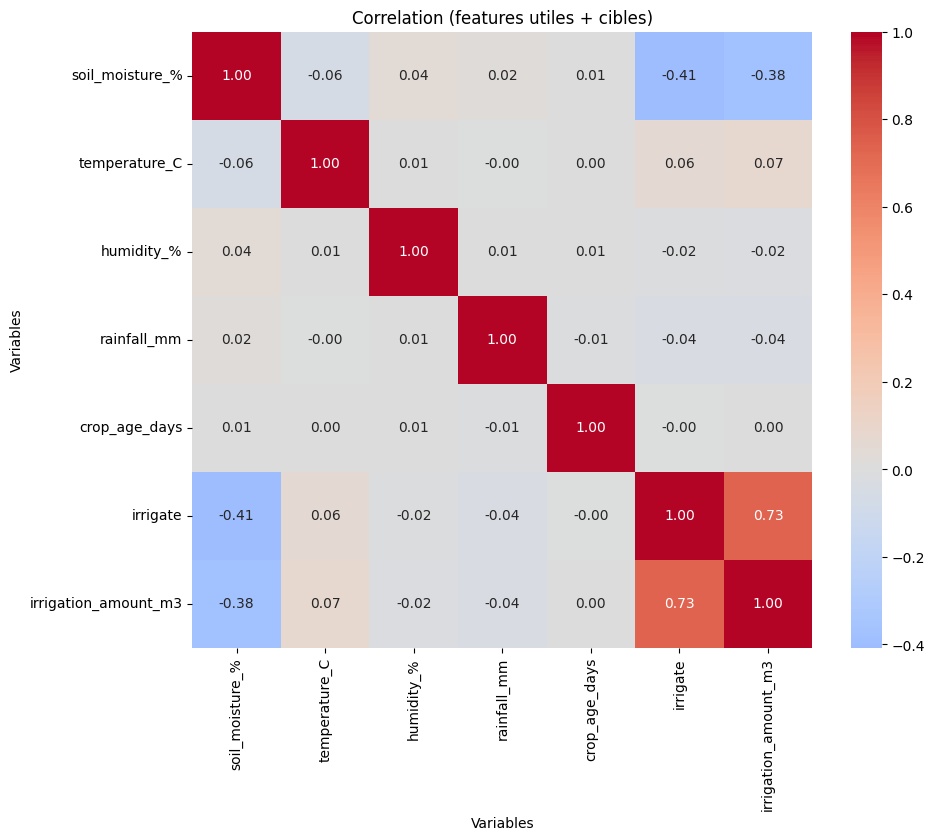

In [6]:
plot_cols = [
    "soil_moisture_%",
    "temperature_C",
    "humidity_%",
    "rainfall_mm",
    "crop_age_days",
    "irrigate",
    "irrigation_amount_m3",
]
plt.figure(figsize=(10, 8))
sns.heatmap(df[plot_cols].corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation (features utiles + cibles)")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.show()

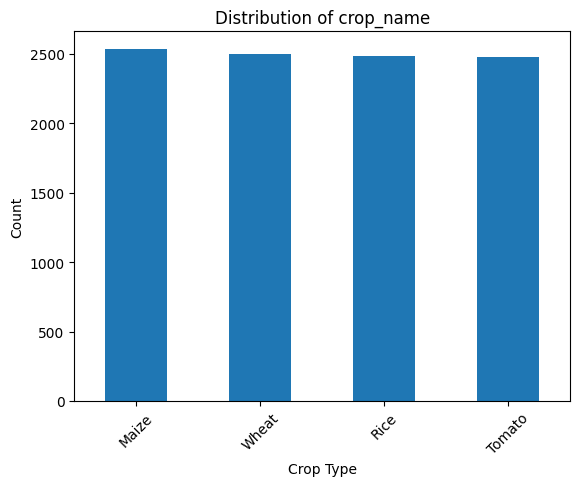

In [7]:
if 'crop_name' in df.columns:
    plt.figure()
    df['crop_name'].value_counts().plot(kind='bar')
    plt.title("Distribution of crop_name")
    plt.xlabel("Crop Type")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

In [8]:
# Selection stricte des features + preprocessing (imputation, MinMax numerique, encodage crop/soil)
SENSOR_COLS = ["soil_moisture_%", "temperature_C", "humidity_%", "rainfall_mm"]
CAT_COLS = ["crop_name", "soil_type"]
NUM_COLS = SENSOR_COLS + ["crop_age_days"]

missing = [c for c in NUM_COLS + CAT_COLS + ["irrigate", "irrigation_amount_m3"] if c not in df.columns]
if missing:
    raise ValueError(f"Colonnes manquantes: {missing}")

X_src = df[NUM_COLS + CAT_COLS].copy()

imp_num = SimpleImputer(strategy="median")
X_num_imp = imp_num.fit_transform(X_src[NUM_COLS])
mm = MinMaxScaler()
X_num = mm.fit_transform(X_num_imp)

encoders: dict = {}
le_crop = LabelEncoder()
crop_fill = X_src["crop_name"].fillna(X_src["crop_name"].mode().iloc[0]).astype(str)
encoders["crop_name"] = le_crop
crop_enc = le_crop.fit_transform(crop_fill)

le_soil = LabelEncoder()
soil_fill = X_src["soil_type"].fillna(X_src["soil_type"].mode().iloc[0]).astype(str)
encoders["soil_type"] = le_soil
soil_enc = le_soil.fit_transform(soil_fill)

X = pd.DataFrame(
    np.column_stack([X_num, crop_enc, soil_enc]),
    columns=NUM_COLS + ["crop_name_enc", "soil_type_enc"],
    index=X_src.index,
)

preproc_bundle = {
    "imputer": imp_num,
    "scaler": mm,
    "label_encoders": encoders,
    "numeric_columns": NUM_COLS,
    "categorical_columns": CAT_COLS,
}

In [9]:
y_class = df["irrigate"]
y_reg = df["irrigation_amount_m3"]  # water_amount

X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class
)

In [10]:
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_class_train)

reg = DecisionTreeRegressor(max_depth=4, random_state=42)
reg.fit(X_train, y_reg_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [11]:
y_pred_class = clf.predict(X_test)
y_pred_reg = reg.predict(X_test)

In [12]:
acc = accuracy_score(y_class_test, y_pred_class)
print(f"Accuracy (irrigate): {acc:.4f}")
print("\nrapport de classification\n")
print(classification_report(y_class_test, y_pred_class))


Accuracy (irrigate): 0.7405

rapport de classification

              precision    recall  f1-score   support

           0       0.76      0.61      0.68       892
           1       0.73      0.85      0.78      1108

    accuracy                           0.74      2000
   macro avg       0.75      0.73      0.73      2000
weighted avg       0.74      0.74      0.74      2000



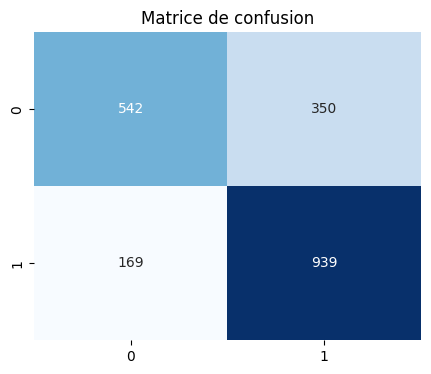

In [13]:
cm = confusion_matrix(y_class_test, y_pred_class)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matrice de confusion")
plt.show()


In [14]:
mae = mean_absolute_error(y_reg_test, y_pred_reg)
mse = mean_squared_error(y_reg_test, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg_test, y_pred_reg)
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

MAE: 154.1101
MSE: 45240.2955
RMSE: 212.6977
R2: 0.3658


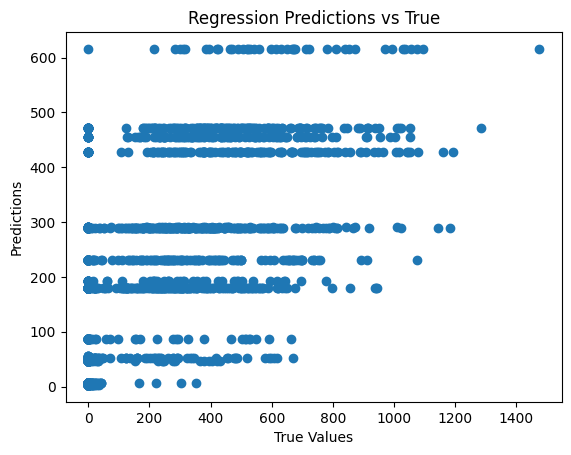

In [15]:
plt.figure()
plt.scatter(y_reg_test, y_pred_reg)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("Regression Predictions vs True")
plt.show()

C:\Users\LENEVO\AppData\Local\Temp\ipykernel_17432\3336789885.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance_clf.head(topn).values, y=feature_importance_clf.head(topn).index, palette='viridis')


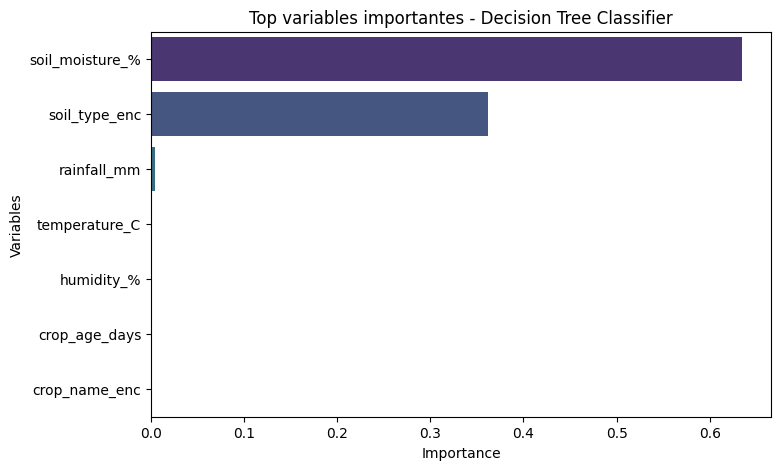

C:\Users\LENEVO\AppData\Local\Temp\ipykernel_17432\3336789885.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance_reg.head(topn).values, y=feature_importance_reg.head(topn).index, palette='magma')


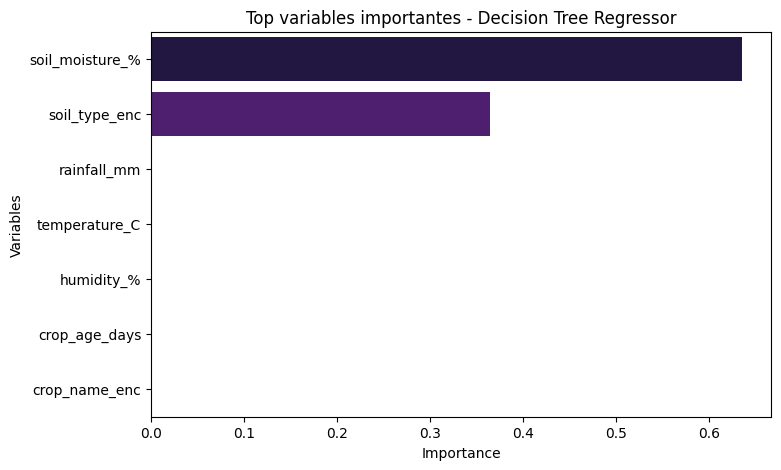

In [16]:
feature_importance_clf = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
feature_importance_reg = pd.Series(reg.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
topn = min(12, len(X.columns))
sns.barplot(x=feature_importance_clf.head(topn).values, y=feature_importance_clf.head(topn).index, palette='viridis')
plt.title('Top variables importantes - Decision Tree Classifier')
plt.xlabel('Importance')
plt.ylabel('Variables')
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance_reg.head(topn).values, y=feature_importance_reg.head(topn).index, palette='magma')
plt.title('Top variables importantes - Decision Tree Regressor')
plt.xlabel('Importance')
plt.ylabel('Variables')
plt.show()

In [18]:
import joblib
import json
from pathlib import Path

from sklearn.tree import export_text


def _repo_root() -> Path:
    """Racine du projet (dossier contenant Smart_irrigation_dataset.csv)."""
    p = Path.cwd().resolve()
    for _ in range(10):
        if (p / "Smart_irrigation_dataset.csv").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError("Smart_irrigation_dataset.csv introuvable (lancez depuis le projet).")


out_dir = _repo_root() / "decision_tree" / "models"
out_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(clf, out_dir / "decision_tree_classifier.joblib")
joblib.dump(reg, out_dir / "decision_tree_regressor.joblib")
joblib.dump(preproc_bundle, out_dir / "decision_tree_preprocessing.joblib")

mm_meta = {
    "numeric_columns": NUM_COLS,
    "data_min": mm.data_min_.tolist(),
    "data_max": mm.data_max_.tolist(),
    "scale": mm.scale_.tolist(),
    "min": mm.min_.tolist(),
    "crop_classes": encoders["crop_name"].classes_.tolist(),
    "soil_classes": encoders["soil_type"].classes_.tolist(),
}
(out_dir / "scaler_encoder_params.json").write_text(json.dumps(mm_meta, indent=2), encoding="utf-8")

feat_list = list(X.columns)
dt_rules = [
    "# Decision Tree — regles interpretables (export_text sklearn)",
    "",
    "## Classification (irrigate)",
    export_text(clf, feature_names=feat_list),
    "",
    "## Regression (water_amount)",
    export_text(reg, feature_names=feat_list),
    "",
]
(out_dir / "dt_rules.txt").write_text("\n".join(dt_rules), encoding="utf-8")

print("Sauvegarder", out_dir.resolve())
for p in sorted(out_dir.iterdir()):
    if p.is_file():
        print(f"  {p.name} ({p.stat().st_size // 1024} Ko)")

Sauvegarder C:\Users\LENEVO\Desktop\11master pf\decision_tree\models
  decision_tree_classifier.joblib (4 Ko)
  decision_tree_preprocessing.joblib (2 Ko)
  decision_tree_regressor.joblib (3 Ko)
  dt_rules.txt (3 Ko)
  scaler_encoder_params.json (0 Ko)
